# Name : Priyanshu Kumar Singh
# OASIS INFOBYTE DATA SCIENCE INTERNSHIP
# TASK 5: Sales Prediction Using Python

*Objective:*  
To analyze the relationship between advertising expenditure and sales, and build machine learning models to predict sales.

*Dataset:* Advertising Dataset

*Features:*
- TV Advertising
- Radio Advertising
- Newspaper Advertising

*Target:*
- Sales

## Project Overview

This project focuses on analyzing advertising expenditure across different media channels and predicting product sales using Machine Learning.

The project includes:
- Data exploration and preprocessing
- Exploratory Data Analysis (EDA)
- Data visualization
- Correlation analysis
- Feature-target relationship analysis
- Machine Learning model development
- Model evaluation
- Residual analysis
- Identification of the most influential advertising channel

In [15]:
#importing libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

## Loading the Dataset

In [16]:
df = pd.read_csv("Advertising.csv")
df

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [17]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 200
Number of Columns: 5


### Observation

The dataset contains advertising expenditure information along with corresponding sales values.

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   radio       200 non-null    float64
 3   newspaper   200 non-null    float64
 4   sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [19]:
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['Unnamed: 0', 'TV', 'radio', 'newspaper', 'sales']


In [20]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Unnamed: 0    0
TV            0
radio         0
newspaper     0
sales         0
dtype: int64


In [21]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [22]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (200, 5)


In [23]:
df.describe()

,Unnamed: 0,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


### Observation

The descriptive statistics provide information about the distribution of advertising expenditure and sales, including mean, standard deviation, minimum and maximum values.

# Exploratory Data Analysis

## Distribution of Sales

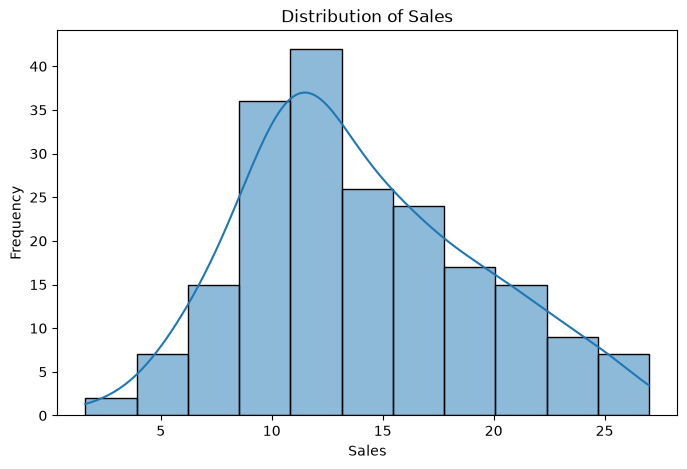

In [25]:
plt.figure(figsize=(8, 5))

sns.histplot(df["sales"], kde=True)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

## TV vs Sales

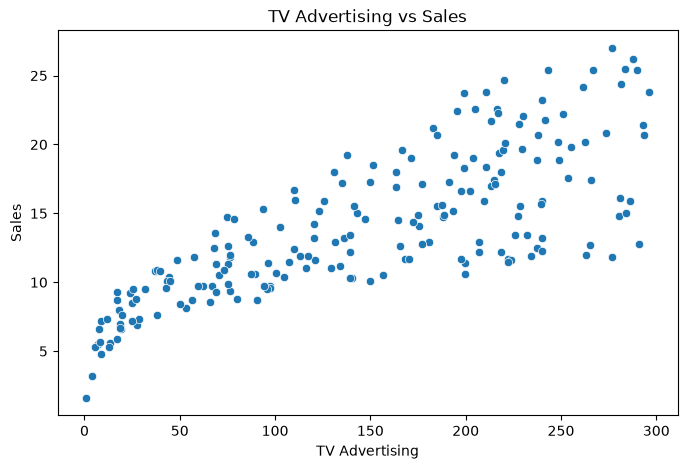

In [27]:
plt.figure(figsize=(8, 5))

sns.scatterplot(x="TV", y="sales", data=df)

plt.title("TV Advertising vs Sales")
plt.xlabel("TV Advertising")
plt.ylabel("Sales")

plt.show()

## Radio vs Sales

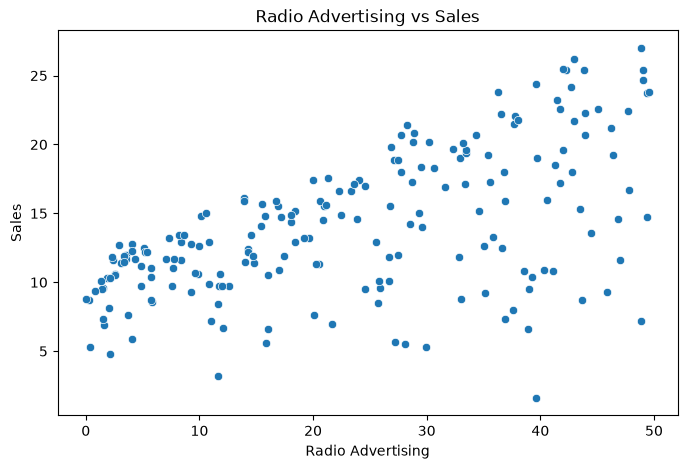

In [30]:
plt.figure(figsize=(8, 5))

sns.scatterplot(x="radio", y="sales", data=df)

plt.title("Radio Advertising vs Sales")
plt.xlabel("Radio Advertising")
plt.ylabel("Sales")

plt.show()

## Newspaper vs Sales

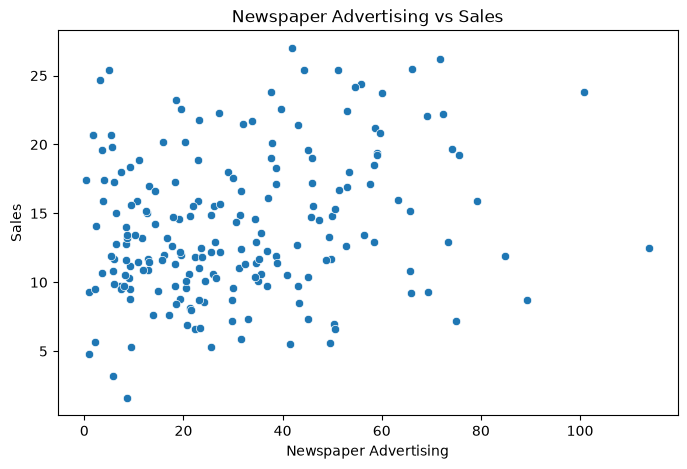

In [32]:
plt.figure(figsize=(8, 5))

sns.scatterplot(x="newspaper", y="sales", data=df)

plt.title("Newspaper Advertising vs Sales")
plt.xlabel("Newspaper Advertising")
plt.ylabel("Sales")

plt.show()

## Pairplot

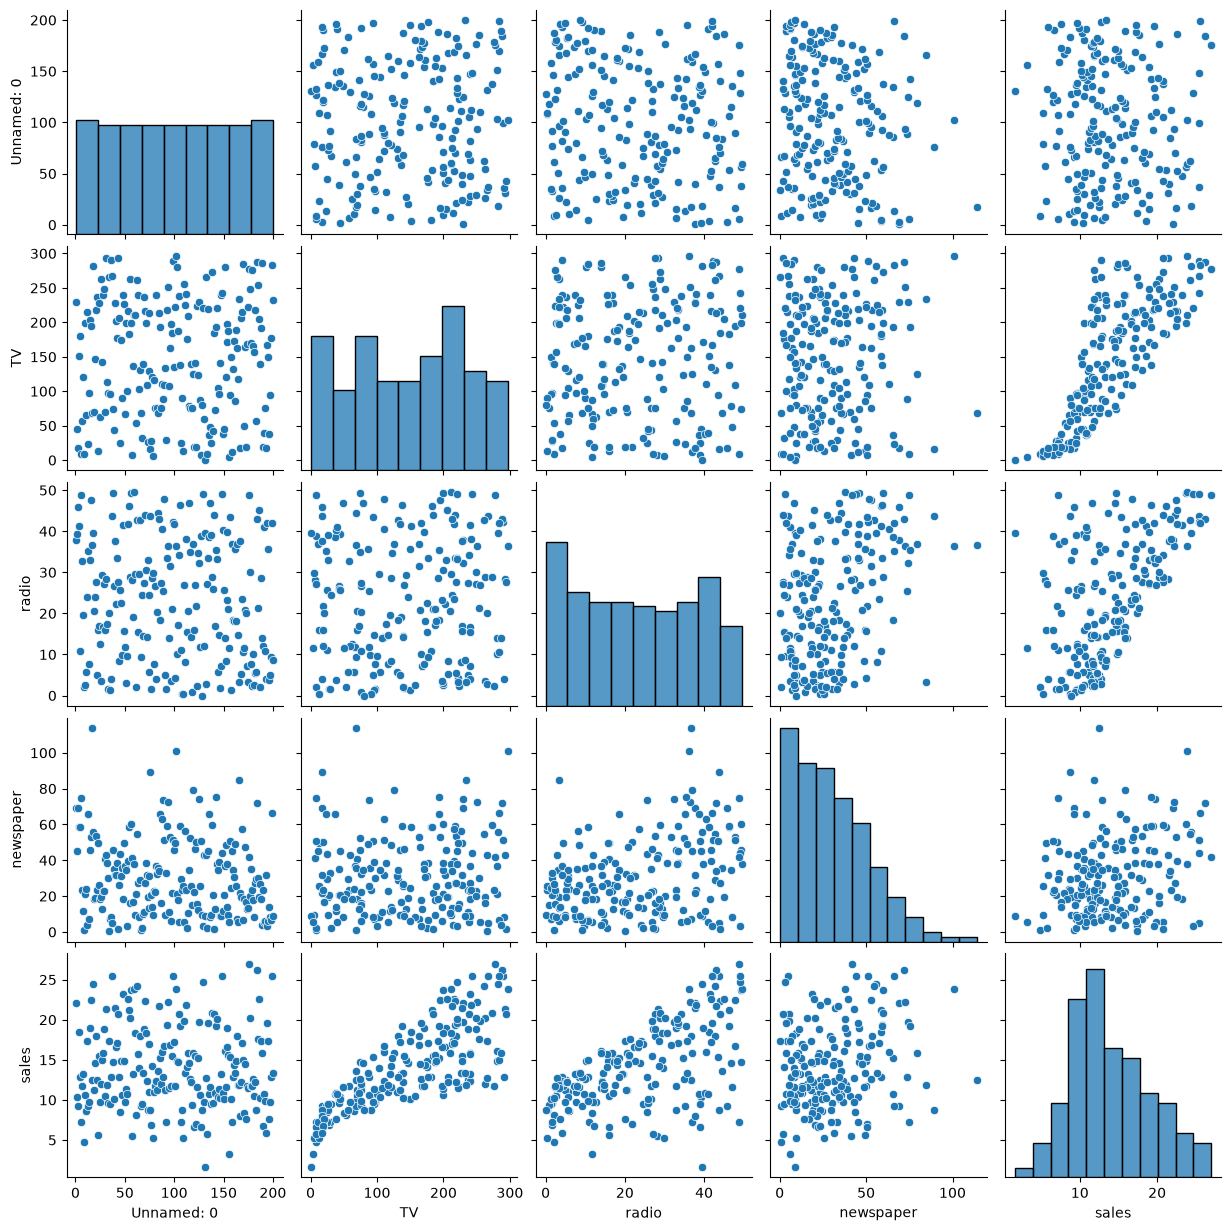

In [33]:
sns.pairplot(df)

plt.show()

### Observation

The pairplot shows the relationships and distributions among TV, Radio, Newspaper and Sales. It helps identify which advertising channels have stronger relationships with sales.

## Correlation Heatmap

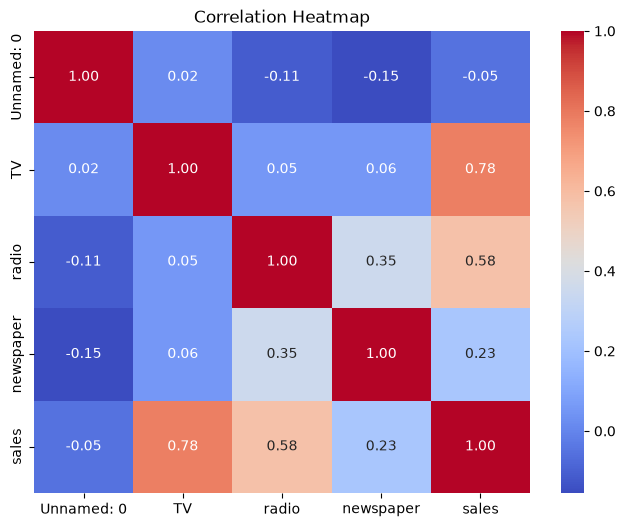

In [34]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

The correlation matrix helps measure the strength and direction of relationships between advertising channels and sales.

## Compare Advertising Channels

In [37]:
advertising_means = df[["TV", "radio", "newspaper"]].mean()

print("Average Advertising Spend:")
print(advertising_means)

Average Advertising Spend:
TV           147.0425
radio         23.2640
newspaper     30.5540
dtype: float64


## Advertising Spend Visualization

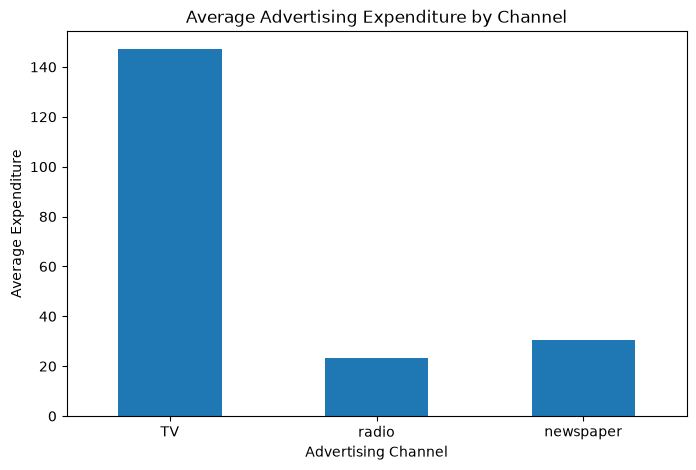

In [38]:
plt.figure(figsize=(8, 5))

advertising_means.plot(kind="bar")

plt.title("Average Advertising Expenditure by Channel")
plt.xlabel("Advertising Channel")
plt.ylabel("Average Expenditure")

plt.xticks(rotation=0)

plt.show()

## Prepare Features and Targets

In [41]:
X = df[["TV", "radio", "newspaper"]]
y = df["sales"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
      TV  radio  newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4

Target:
0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: sales, dtype: float64


## Train-Test Split

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 160
Testing samples: 40


### Observation

The dataset is divided into training and testing sets. The training data is used to build the models, while the testing data is used to evaluate their performance on unseen data.

# Model-1: LINEAR REGRESSION

## Train Linear Regression

In [46]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[0.04,0.19,0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['TV','radio','newspaper']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.979
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


## Predictions

In [47]:
y_pred_lr = linear_model.predict(X_test)

print("Predictions:")
print(y_pred_lr[:10])

Predictions:
[16.4080242  20.88988209 21.55384318 10.60850256 22.11237326 13.10559172
 21.05719192  7.46101034 13.60634581 15.15506967]


## Linear Regression Evaluation

In [48]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(
    mean_squared_error(y_test, y_pred_lr)
)

r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance")
print("--------------------------------")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)

Linear Regression Performance
--------------------------------
MAE : 1.4607567168117606
RMSE: 1.7815996615334506
R²  : 0.899438024100912


### Observation

The Linear Regression model provides a baseline for predicting sales based on advertising expenditure across TV, Radio and Newspaper channels.

# Model-2: RANDOM FOREST REGRESSION

## Train Random Forest

In [49]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

# Predictions

In [50]:
y_pred_rf = rf_model.predict(X_test)

print("Predictions:")
print(y_pred_rf[:10])

Predictions:
[17.765  21.6665 20.655   6.7395 23.096  13.5155 22.486   9.6625 11.8545
 15.504 ]


## Random Forest Evaluation

In [51]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("--------------------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Performance
--------------------------------
MAE : 0.6289250000000022
RMSE: 0.7576571454160537
R²  : 0.9818130864772012


# MODEL COMPARISON

## Create Comparison Table

In [53]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae_lr,
        mae_rf
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf
    ],
    "R2 Score": [
        r2_lr,
        r2_rf
    ]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.460757,1.781600,0.899438
1,Random Forest,0.628925,0.757657,0.981813


## Compare R² Scores

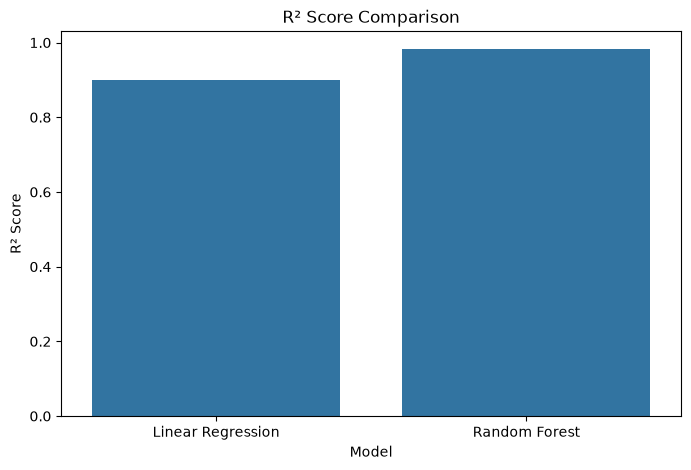

In [54]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x="Model",
    y="R2 Score",
    data=comparison
)

plt.title("R² Score Comparison")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.show()

## Compare MAE

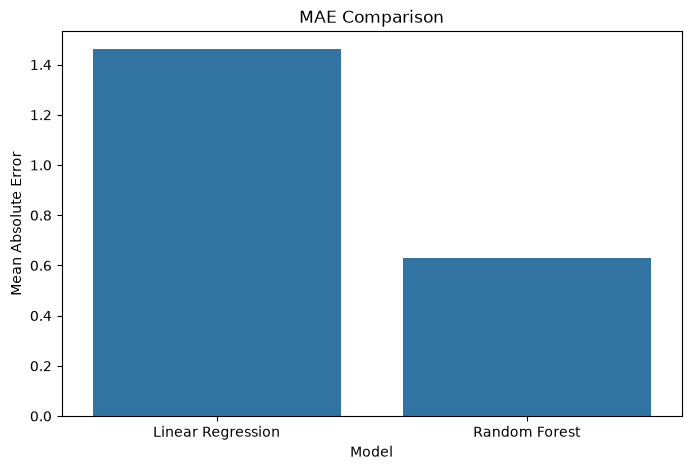

In [55]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x="Model",
    y="MAE",
    data=comparison
)

plt.title("MAE Comparison")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")

plt.show()

## Select Best Model

In [56]:
best_model_row = comparison.loc[
    comparison["R2 Score"].idxmax()
]

print("Best Performing Model:")
print(best_model_row["Model"])

print("\nBest R² Score:")
print(best_model_row["R2 Score"])

Best Performing Model:
Random Forest

Best R² Score:
0.9818130864772012


### Observation

The model with the highest R² score provides the strongest overall fit among the evaluated models. Lower MAE and RMSE values also indicate better prediction accuracy.

# ACTUAL VS PREDICTED

## Actual vs Predicted

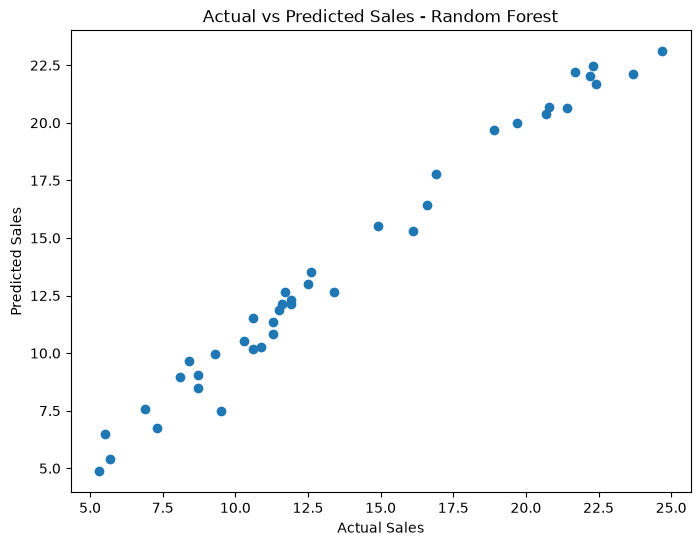

In [57]:
best_model_name = best_model_row["Model"]

if best_model_name == "Linear Regression":
    best_predictions = y_pred_lr
else:
    best_predictions = y_pred_rf

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_predictions
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title(
    f"Actual vs Predicted Sales - {best_model_name}"
)

plt.show()

### Observation

The Actual vs Predicted plot helps visualize how closely the model's predictions follow the actual sales values. Predictions closer to the overall trend indicate better model performance.

# RESIDUAL ANALYSIS

## Calculate Residuals

In [58]:
residuals = y_test - best_predictions

print("First 10 residuals:")
print(residuals.head(10))

First 10 residuals:
95    -0.8650
15     0.7335
30     0.7450
158    0.5605
128    1.6040
115   -0.9155
69    -0.1860
170   -1.2625
174   -0.3545
45    -0.6040
Name: sales, dtype: float64


## Residual Plot

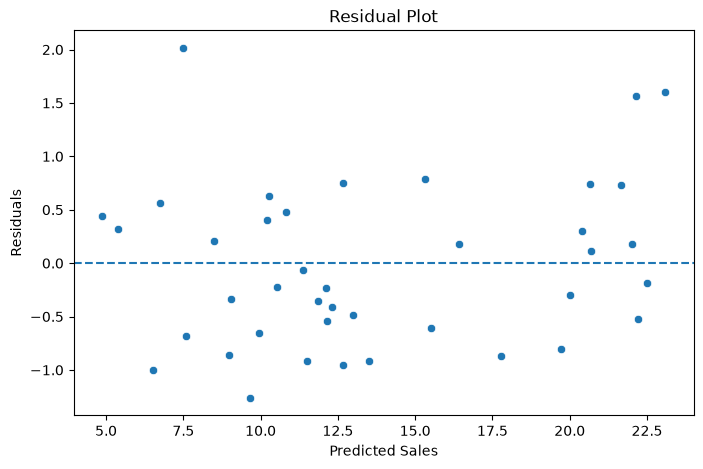

In [59]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=best_predictions,
    y=residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

### Observation

Residual analysis helps identify how much the model's predictions differ from the actual sales values. A relatively random distribution of residuals around zero indicates that the model captures the underlying relationship reasonably well.

# Feature Importance

Random Forest gives us feature importance, so we can identify which advertising channel contributes most to the prediction.

## Feature Importance

In [60]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,TV,0.624729
1,radio,0.362129
2,newspaper,0.013142


## Feature Importance Visualization

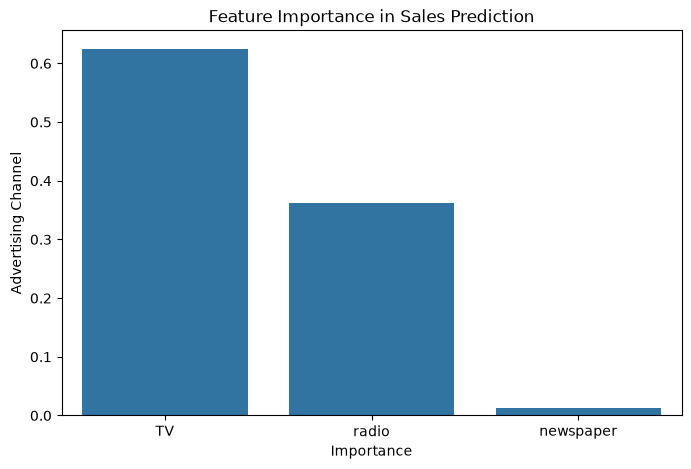

In [62]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x="Feature",
    y="Importance",
    data=feature_importance
)

plt.title("Feature Importance in Sales Prediction")
plt.xlabel("Importance")
plt.ylabel("Advertising Channel")

plt.show()

## Highest Impact Channel

In [63]:
highest_impact = feature_importance.iloc[0]

print(
    f"The most influential advertising channel is: "
    f"{highest_impact['Feature']}"
)

print(
    f"Feature importance: "
    f"{highest_impact['Importance']:.4f}"
)

The most influential advertising channel is: TV
Feature importance: 0.6247


### Observation

Feature importance indicates the relative contribution of each advertising channel to the Random Forest model's predictions. The channel with the highest importance has the strongest influence within this model.

# FINAL SAMPLE PREDICTION

## Predict Sales for a New Advertising Budget

In [66]:
new_advertising_data = pd.DataFrame({
    "TV": [150],
    "radio": [30],
    "newspaper": [20]
})

predicted_sales = rf_model.predict(
    new_advertising_data
)

print(
    "Predicted Sales:",
    predicted_sales[0]
)

Predicted Sales: 16.72300000000001


## Final Results

In [67]:
print("========== FINAL RESULTS ==========")

print("\nLinear Regression:")
print("MAE :", round(mae_lr, 4))
print("RMSE:", round(rmse_lr, 4))
print("R²  :", round(r2_lr, 4))

print("\nRandom Forest:")
print("MAE :", round(mae_rf, 4))
print("RMSE:", round(rmse_rf, 4))
print("R²  :", round(r2_rf, 4))

print("\nBest Model:", best_model_name)
print(
    "Most Influential Channel:",
    highest_impact["Feature"]
)

========== FINAL RESULTS ==========

Linear Regression:
MAE : 1.4608
RMSE: 1.7816
R²  : 0.8994

Random Forest:
MAE : 0.6289
RMSE: 0.7577
R²  : 0.9818

Best Model: Random Forest
Most Influential Channel: TV


# FINAL CONCLUSION

# Conclusion

In this project, an end-to-end Machine Learning workflow was developed to analyze advertising expenditure and predict sales.

The project involved:

- Data exploration and preprocessing
- Exploratory Data Analysis
- Pairplot and scatter plot visualization
- Correlation analysis
- Train-test splitting
- Linear Regression
- Random Forest Regression
- Model evaluation using MAE, RMSE and R²
- Actual vs. predicted analysis
- Residual analysis
- Feature importance analysis

The performance of Linear Regression and Random Forest was compared to identify the better-performing model.

Feature importance analysis was also used to identify the advertising channel with the strongest influence on the model's sales predictions.

Overall, this project strengthened my understanding of **regression, model evaluation, data visualization and the complete Machine Learning workflow**.